# Importing Required Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Loading Dataset

In [4]:
df = pd.read_csv("School data.csv")

# Data Understanding

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   str    
 1   District                       5200 non-null   str    
 2   Block                          5200 non-null   str    
 3   Urban_Rural                    5200 non-null   str    
 4   %_Math_Score                   5200 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          5200 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             5200 non-null   float64
 12  Functional_Toilets             5200 non-null   int64  
 13 

In [14]:
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate,Avg_Total_Score,Infra_Score
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9,47.026667,2.0
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,29.8,5.8,1,1,0.0,0,0,36.1,4.0,40.6,82.806667,1.0
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6,43.750000,2.0
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3,42.610000,2.0
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3,48.780000,2.0


In [4]:
df.tail()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
5195,SCH_5196,District_A,Block_A3,Rural,NaN,63.21,67.84,17.5,13.7,0,1,0.0,1,0,24.8,0.0,52.5
5196,SCH_5197,District_A,Block_A1,Urban,64.93,65.44,43.21,37.4,13.3,0,1,1.0,1,1,24.3,32.1,52.1
5197,SCH_5198,District_B,Block_B1,Rural,67.46,66.19,67.65,40.3,12.7,2,0,0.0,1,0,34.3,19.7,31.1
5198,SCH_5199,District_C,Block_C2,Urban,58.35,74.95,57.28,35.1,0.0,2,1,0.0,1,1,23.8,3.4,33.6
5199,SCH_5200,District_C,Block_C2,Urban,38.73,47.56,35.42,29.3,12.4,3,1,0.0,1,1,23.7,35.2,52.5


In [5]:
print(f"Dataset Shape: {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)

Dataset Shape: (5200, 17)

Column Data Types:
School_ID                            str
District                             str
Block                                str
Urban_Rural                          str
%_Math_Score                     float64
%_Language_Score                 float64
%_Science_Score                  float64
Teacher_Student_Ratio            float64
Avg_Teacher_Experience_Years     float64
Teacher_Trainings_Attended         int64
Electricity_Available              int64
Internet_Available               float64
Functional_Toilets                 int64
Library_Available                  int64
%_Marginalized_Students          float64
%_Students_With_Home_Internet    float64
Parent_Literacy_Rate             float64
dtype: object


In [5]:
df.describe()

,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
count,4942.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,4940.000000,5200.000000,5200.000000,5200.000000,5200.000000,4941.000000
mean,60.055898,62.970896,61.338762,29.980951,8.096596,1.995385,0.895577,0.295344,0.954423,0.483462,30.401288,16.770077,49.776644
std,15.106160,16.569802,18.025438,9.957824,3.916906,1.430434,0.305838,0.456243,0.208586,0.499774,11.916650,12.773571,16.936643
min,0.326857,1.380000,1.510000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000
25%,49.582500,51.520000,48.890000,23.100000,5.400000,1.000000,1.000000,0.000000,1.000000,0.000000,22.300000,6.200000,38.400000
50%,59.850000,63.030000,61.150000,29.800000,8.000000,2.000000,1.000000,0.000000,1.000000,0.000000,31.000000,15.200000,49.500000
75%,70.630000,74.452500,73.950000,36.600000,10.800000,3.000000,1.000000,1.000000,1.000000,1.000000,38.800000,25.300000,60.800000
max,107.344878,100.000000,100.000000,100.000000,22.700000,9.000000,1.000000,1.000000,1.000000,1.000000,73.100000,66.000000,150.000000


# Data Cleaning

In [6]:
# Checking Missing Values
df.isnull().sum()

School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64

In [7]:
# Handling Missing Values
df['%_Math_Score'] = df['%_Math_Score'].fillna(df['%_Math_Score'].median())
df['Teacher_Student_Ratio'] = df['Teacher_Student_Ratio'].fillna(df['Teacher_Student_Ratio'].median())
df['Parent_Literacy_Rate'] = df['Parent_Literacy_Rate'].fillna(df['Parent_Literacy_Rate'].median())
df['Internet_Available'] = df['Internet_Available'].fillna(df['Internet_Available'].mode()[0])

In [9]:
# Fixing Anomalies
df['%_Math_Score'] = df['%_Math_Score'].clip(0, 100)
df['Parent_Literacy_Rate'] = df['Parent_Literacy_Rate'].clip(0, 100)

In [10]:
# Removing Duplicate Values
df.drop_duplicates(inplace=True)
print("Data Cleaning Complete.")

Data Cleaning Complete.


# Feature Engineering

In [7]:
df['Avg_Total_Score'] = df[['%_Math_Score', '%_Language_Score', '%_Science_Score']].mean(axis=1)
def infra_category(x): 
    if x <= 1: 
        return 'Low' 
    elif x <= 3: 
        return 'Medium' 
    else: 
        return 'High'
df['Infra_Score'] = (df['Electricity_Available'] + df['Internet_Available'] + df['Functional_Toilets'] + df['Library_Available'])

# Exploratory Data Analysis

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

* Univariate Analysis

*Distribution of Overall Student Performance (Avg_Total_Score)*

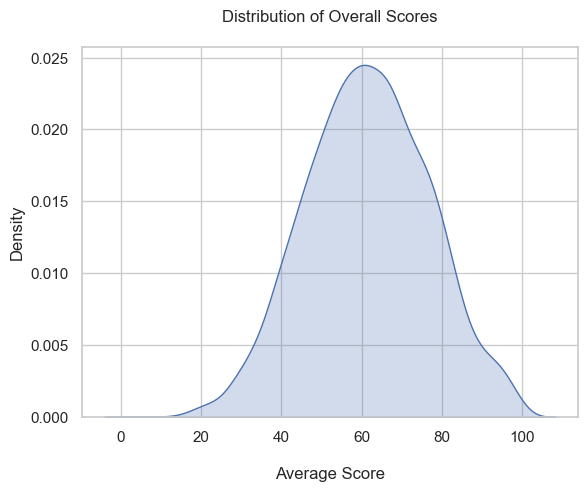

In [61]:
sns.kdeplot(df['Avg_Total_Score'], fill=True)
plt.title('Distribution of Overall Scores\n')
plt.xlabel('\nAverage Score')

plt.show()

*Distribution of Schools by Location (Urban vs Rural)*

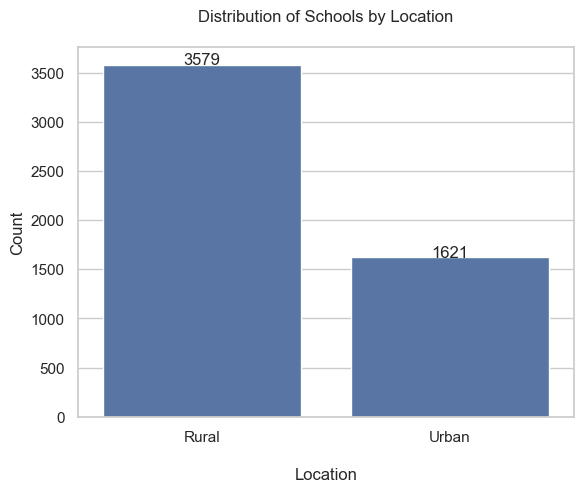

In [60]:
sns.countplot(x='Urban_Rural', data=df)

counts = df['Urban_Rural'].value_counts()
for i, val in enumerate(counts):
    plt.text(i, val, str(val), ha='center')

plt.title('Distribution of Schools by Location\n')
plt.xlabel('\nLocation')
plt.ylabel('Count')

plt.show()

*Distribution of Schools by Infrastructure Level (Infra_Score)*

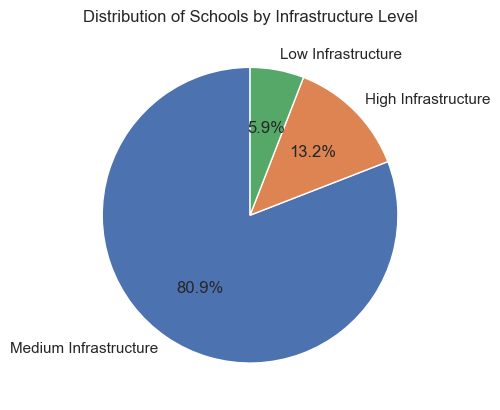

In [84]:
def infra_category(x):
    if x <= 1:
        return 'Low Infrastructure'
    elif x <= 3:
        return 'Medium Infrastructure'
    else:
        return 'High Infrastructure'
df['Infra_Level'] = df['Infra_Score'].apply(infra_category)
sizes = df['Infra_Level'].value_counts()
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%', startangle=90)

plt.title('Distribution of Schools by Infrastructure Level')

plt.show()

*Distribution of Teacher-Student Ratio*

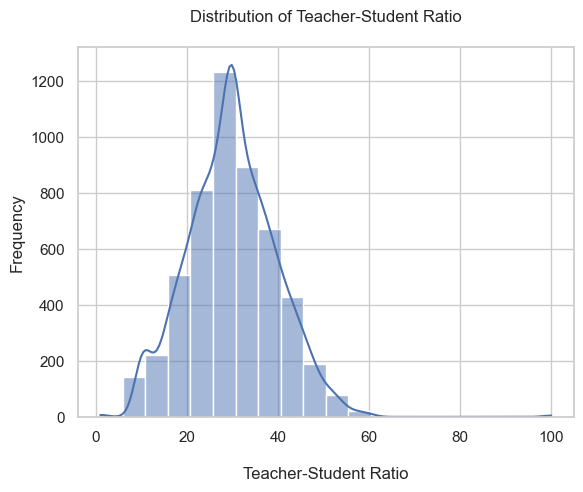

In [62]:
sns.histplot(df['Teacher_Student_Ratio'], bins=20, kde=True)

plt.title('Distribution of Teacher-Student Ratio\n')
plt.xlabel('\nTeacher-Student Ratio')
plt.ylabel('Frequency')

plt.show()

* Bivariate Analysis

*Impact of Infrastructure Level on Student Performance*

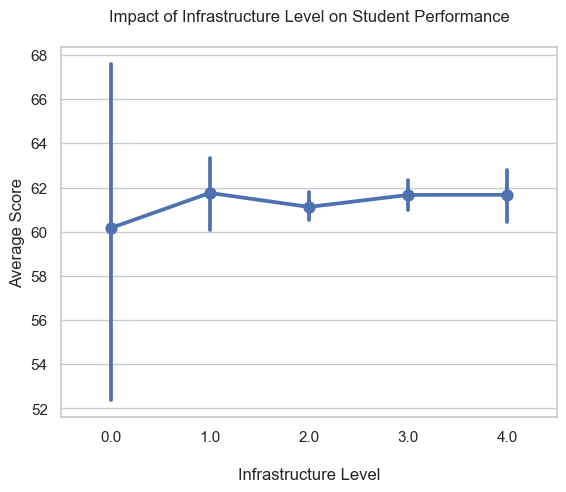

In [63]:
sns.pointplot(x='Infra_Score', y='Avg_Total_Score', data=df)

plt.title('Impact of Infrastructure Level on Student Performance\n')
plt.xlabel('\nInfrastructure Level')
plt.ylabel('Average Score')

plt.show()

*Effect of Teacher Training on Student Performance*

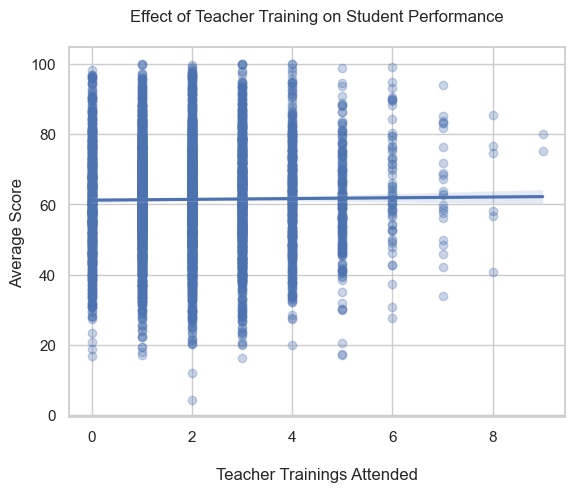

In [67]:
sns.regplot(x='Teacher_Trainings_Attended', y='Avg_Total_Score', data=df, scatter_kws={'alpha':0.3})

plt.title('Effect of Teacher Training on Student Performance\n')
plt.xlabel('\nTeacher Trainings Attended')
plt.ylabel('Average Score')

plt.show()

*Comparison of Student Performance Across Top Districts*

In [50]:
top_districts = df.groupby('District')['Avg_Total_Score'].mean().sort_values(ascending=False).head(5).index

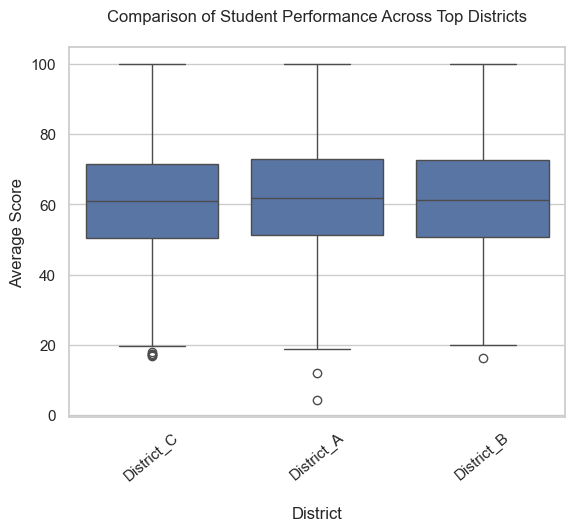

In [68]:
sns.boxplot(x='District', y='Avg_Total_Score', data=df[df['District'].isin(top_districts)])

plt.xticks(rotation=40)
plt.title('Comparison of Student Performance Across Top Districts\n')
plt.xlabel('\nDistrict')
plt.ylabel('Average Score')

plt.show()

* Correlation Analysis

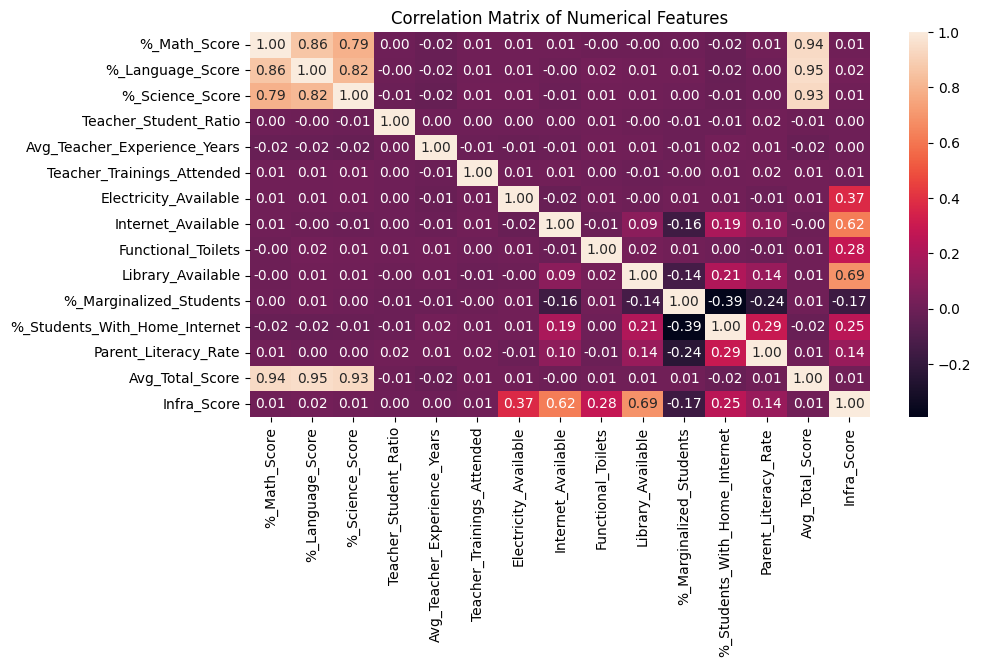

In [22]:
plt.figure(figsize=(10,5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,fmt=".2f")

plt.title('Correlation Matrix of Numerical Features')

plt.show()

# Key Insights

In [21]:
print("\n----Insights----\n")

# Insight 1: Infrastructure
print("1. Infrastructure Impact:")
print(f"   Avg score increases slightly from {infra_perf.min():.2f} to {infra_perf.max():.2f}, indicating minimal impact of infrastructure on performance.\n")

# Insight 2: Teacher Experience
print("2. Teacher Experience:")
print(f"   Correlation = {corr_exp:.3f}, showing negligible relationship with student performance.\n")

# Insight 3: Teacher Training
print("3. Teacher Training:")
print(f"   Correlation = {corr_training:.3f}, indicating almost no impact on scores.\n")

# Insight 4: Internet Availability
print("4. Internet Access:")
print(f"   Avg scores are {internet_perf.iloc[0]:.2f} (No) vs {internet_perf.iloc[1]:.2f} (Yes),")
print("   showing no significant difference.\n")

# Insight 5: Overall Observation
print("5. Overall Observation:")
print("   Most variables show very weak correlations, suggesting other hidden factors may influence student performance.\n")


----Insights----

1. Infrastructure Impact:
   Avg score increases slightly from 60.16 to 62.20, indicating minimal impact of infrastructure on performance.

2. Teacher Experience:
   Correlation = -0.021, showing negligible relationship with student performance.

3. Teacher Training:
   Correlation = 0.011, indicating almost no impact on scores.

4. Internet Access:
   Avg scores are 61.52 (No) vs 61.45 (Yes),
   showing no significant difference.

5. Overall Observation:
   Most variables show very weak correlations, suggesting other hidden factors may influence student performance.



# Model Evaluation

In [16]:
X = df[
    [
        'Avg_Teacher_Experience_Years',
        'Teacher_Trainings_Attended',
        'Infra_Score',
        'Teacher_Student_Ratio',
        'Parent_Literacy_Rate',
        '%_Students_With_Home_Internet'
    ]
]

y = df['Avg_Total_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance (Random Forest) :")
print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Performance (Random Forest) :
R² Score: -0.0444
MAE: 13.04
RMSE: 16.09
